OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k


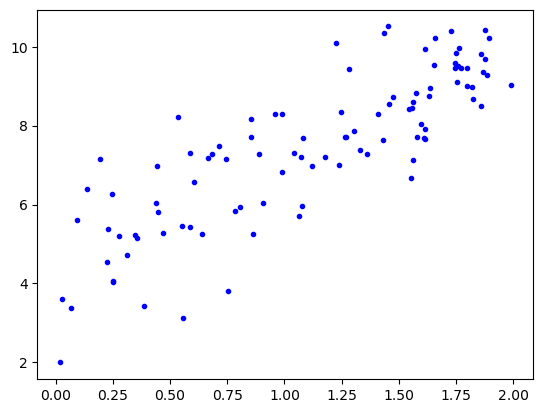

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

X = 2 * torch.rand(100,1)

y = 4 + 3* X + torch.randn(100,1)

plt.plot(X.numpy(), y.numpy(), "b.")
plt.show()


In [8]:
y
y.shape

torch.Size([100, 1])

In [10]:
y=y.squeeze()
y.shape

torch.Size([100])

In [11]:
import torch.nn as nn

model = nn.Linear(in_features=1, out_features=1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

epochs = 200

for epoch in range(epochs):
    y_pred = model(X).squeeze()
    loss = loss_fn(y_pred, y)
    optimizer.zero_grad()
    loss.backward()     # optimalizacja gradientowa
    optimizer.step()
    
    if epoch %20 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.4f}")

        

Epoch 0: loss = 83.6365
Epoch 20: loss = 1.2272
Epoch 40: loss = 1.1435
Epoch 60: loss = 1.1156
Epoch 80: loss = 1.1063
Epoch 100: loss = 1.1032
Epoch 120: loss = 1.1022
Epoch 140: loss = 1.1019
Epoch 160: loss = 1.1018
Epoch 180: loss = 1.1017


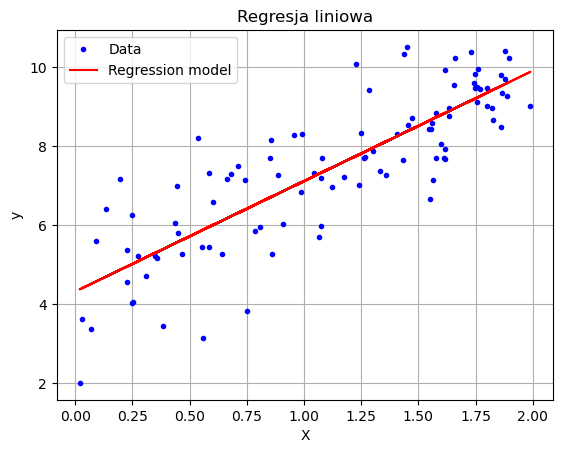

In [13]:
# Wykres z dopasowana prosta regresji

with torch.no_grad():
    predicted = model(X).detach()
    
plt.plot(X.numpy(), y.numpy(), "b.", label="Data")
plt.plot(X.numpy(), predicted.numpy(), "r-", label="Regression model")
plt.legend()
plt.title("Regresja liniowa")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [14]:
# Regresja logistyczna

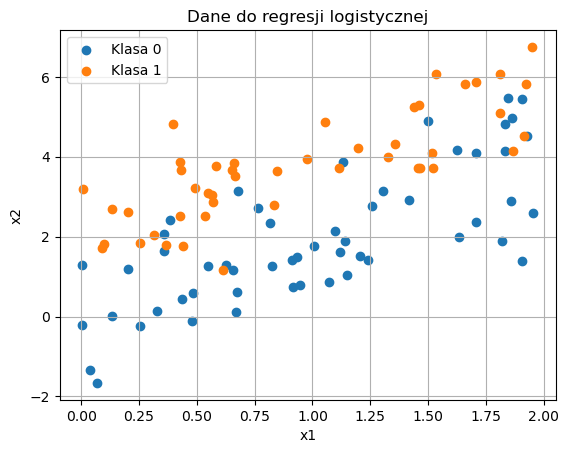

In [17]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

y = torch.randint(0, 2, (100,))

xs = 2* torch.rand(100,1)    # shape: (100,1)
x2 = 1 + 2* xs + torch.randn(100,1) + (y.reshape(100,1)*2-1) * 1.0

# Zlaczone cechy wyjsciowe

X = torch.cat((xs,x2),dim=1)   # shape: (100,2)
plt.scatter(X[y == 0, 0], X[y == 0,1], label="Klasa 0")
plt.scatter(X[y == 1, 0], X[y == 1,1], label="Klasa 1")

plt.title("Dane do regresji logistycznej")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()




In [20]:
y.shape

torch.Size([100])

In [22]:
y.float().unsqueeze(1).shape

torch.Size([100, 1])

In [21]:
X.shape

torch.Size([100, 2])

In [23]:
y = y.float().unsqueeze(1)

# e. Model regresji logistycznej
model = nn.Sequential(
    nn.Linear(2,1),
    nn.Sigmoid()
)

# 4. Funkcja straty i optymalizator
criterion = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for epoch in range(epochs):
    y_pred = model(X)
    loss = criterion(y_pred, y)
    optimizer.zero_grad()
    loss.backward()     # optimalizacja gradientowa
    optimizer.step()
    
    if epoch %20 == 0:
        print(f"Epoch {epoch}: loss = {loss.item():.4f}")


Epoch 0: loss = 0.6903
Epoch 20: loss = 0.5901
Epoch 40: loss = 0.5522
Epoch 60: loss = 0.5229
Epoch 80: loss = 0.4998
Epoch 100: loss = 0.4813
Epoch 120: loss = 0.4662
Epoch 140: loss = 0.4537
Epoch 160: loss = 0.4432
Epoch 180: loss = 0.4343


In [28]:
with torch.no_grad():
    y_pred = model(X)
    preds = (y_pred>0.5).float()
    
accuracy = (preds == y).float().mean()
print(f"\nDokladnosc predykcji: {accuracy.item() * 100:.2f}%")


Dokladnosc predykcji: 82.00%


In [26]:
# 7. Wizualizacja granicy decyzyjnej

def plot_decision_boundary(model, X, y):
    x_min, x_max = 
    ...
    ...
    ...

tensor(0.8200)